# ¡Hola Marcos! 😊

Mi nombre es **Alejandro Castellanos** y hoy voy a continuar el proceso de revisión realizado por **Dot**. A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**





<div class="alert alert-block alert-success">
<b>Comentario General del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Noté que en esta iteración no aparecen los comentarios que te hizo **Dot** anteriormente, esto puede pasar si no trabajas sobre el notebook que ya fue revisado y envías un nuevo archivo. **Recuerda que es necesario que mantener todos los comentarios en las diferentes iteraciones con el fin de poder hacer una trazabilidad de tu proyecto**

Ahora bien respecto a esta iteración has demostrado habilidades avanzadas en análisis de información, integración y manejo de múltiples datasets, así como un uso efectivo de visualizaciones que enriquecen la presentación de los hallazgos, haciendo que los datos sean claros y fáciles de interpretar. 

En el apartado de las pruebas de hipótesis aunque, de manera general, la implementación es correcta, para futuros análisis te recomiendo incluir una etapa previa con la prueba de Levene con el fin de verificar la igualdad de varianzas, lo cual contribuye a asegurar la validez estadística de los resultados.

Este proyecto refleja tu dominio en procesamiento y visualización de datos, y tu capacidad para obtener conclusiones relevantes que aportan valor a la toma de decisiones. Lograste un equilibrio excelente entre habilidades técnicas, analíticas y estratégicas.

Éxitos en tu próximo Sprint 🚀

*Estado del Proyecto:* **Aprobado**

</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
pd.set_option('display.max_columns', None)
plt.style.use('default')

## Cargar datos

In [70]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv') 
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Preparar los datos

In [71]:
users.info()
users.head()

calls.info()
calls.head()

messages.info()
messages.head()

internet.info()
internet.head()

plans.info()
plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
<class 'pandas.core.frame.D

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


En esta etapa realice una exploración inicial de los datos con el objetivo de comprender la estructura de cada tabla, los tipos
de datos y la presencia de valores ausentes.

la tabla (USERS) contiene datos de 500 clientes y presenta valores ausentes únicamente en la columna churn_date, lo cual es esperado, ya que indica usuarios que aún se encuentran activos.

Las tablas calls, messages e internet no presentan valores faltantes. Sin embargo, las columnas que representan fechas se encuentran en formato object, por lo que será necesario convertirlas a tipo datetime en pasos posteriores.

La tabla plans contiene información completa sobre las dos tarifas ofrecidas por la empresa y no presenta inconsistencias.

En esta fase no se realizaron modificaciones a los datos, ya que el objetivo fue únicamente identificar posibles problemas y preparar el análisis posterior. 


## Tarifas

In [8]:
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [9]:
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


A partir de la información general y la muestra de datos del DataFrame plans, se observa que el conjunto de datos contiene únicamente dos registros, correspondientes a las tarifas Surf y Ultimate.

Todas las columnas presentan valores completos, sin datos ausentes, y los tipos de datos son adecuados para el análisis posterior. Las variables numéricas, como los minutos incluidos, mensajes incluidos, datos incluidos y precios por excedente, se encuentran correctamente definidas como valores enteros o flotantes según corresponde.

La columna plan_name se encuentra en formato de texto (object), lo cual es apropiado, ya que será utilizada como clave para relacionar esta tabla con la información de los usuarios.

En esta etapa no se identifican problemas que requieran limpieza o correcciones adicionales, por lo que el DataFrame se encuentra listo para ser utilizado en los siguientes pasos del análisis.

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [10]:

users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')

calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')


users.info()
calls.info()
messages.info()
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[

A partir de la exploración inicial de los datos, se identificó que las columnas que representan fechas se encontraban en formato object, lo cual dificulta el análisis temporal y la agregación mensual de los datos.

Por esta razón, se convirtieron las columnas de fechas al tipo datetime en todas las tablas correspondientes. No se identificaron otros problemas obvios que requirieran correcciones adicionales en esta etapa.

## Enriquecer los datos

In [11]:
calls['month'] = calls['call_date'].dt.to_period('M')
messages['month'] = messages['message_date'].dt.to_period('M')
internet['month'] = internet['session_date'].dt.to_period('M')

users['reg_month'] = users['reg_date'].dt.to_period('M')

Con el objetivo de facilitar el análisis posterior y las agregaciones mensuales, se agregaron columnas adicionales que representan el mes de la actividad para las tablas de llamadas, mensajes y uso de internet.

Estas columnas permitirán agrupar los datos de manera más eficiente y realizar cálculos mensuales por usuario en los siguientes pasos del proyecto.

## Usuarios/as

In [12]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
 8   reg_month   500 non-null    period[M]     
dtypes: datetime64[ns](2), int64(2), object(4), period[M](1)
memory usage: 35.3+ KB


In [13]:
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018-12
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018-10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,2018-01
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,2018-05


A partir de la revisión de la información general y la muestra de datos del DataFrame users, se observa que el conjunto de datos contiene 500 registros y se encuentra correctamente estructurado.

Las columnas que representan fechas se encuentran en formato datetime, lo que permitirá realizar análisis temporales sin inconvenientes. La columna churn_date presenta valores ausentes, lo cual es esperado, ya que indica usuarios que aún se encuentran activos.

No se identificaron problemas relacionados con tipos de datos incorrectos o inconsistencias en la información, por lo que no se requirieron correcciones adicionales en esta etapa.

### Corregir los datos

In [14]:

# No se realizaron correcciones en el DataFrame 'users'
# Los datos se encuentran correctamente estructurados para el análisis posterior



### Enriquecer los datos

In [15]:
users['is_active'] = users['churn_date'].isna()

Con el objetivo de enriquecer el conjunto de datos de usuarios, se agregó una variable adicional que indica si el usuario se encuentra activo o no.

Esta variable se construyó a partir de la columna churn_date, considerando como activos a aquellos usuarios que no presentan fecha de cancelación.

Este factor adicional podrá resultar útil en análisis posteriores sin afectar la estructura original de los datos.

## Llamadas

In [16]:
calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
 4   month      137735 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 5.3+ MB


In [17]:
calls.head()


,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,8.52,2018-12
1,1000_145,1000,2018-12-27,13.66,2018-12
2,1000_247,1000,2018-12-27,14.48,2018-12
3,1000_309,1000,2018-12-28,5.76,2018-12
4,1000_380,1000,2018-12-30,4.22,2018-12


A partir de la revisión del DataFrame calls, se observa que el conjunto de datos contiene más de 137 mil registros y no presenta valores ausentes.

La columna duration se encuentra en formato numérico (float64) y representa la duración de las llamadas en minutos, lo cual es consistente con el diccionario de datos. Aunque los valores no están redondeados, esto no representa un problema en esta etapa, ya que el redondeo por llamada se aplicará posteriormente de acuerdo con las reglas del negocio de Megaline.

Las columnas de fecha y mes se encuentran correctamente definidas y permitirán realizar agregaciones mensuales en pasos posteriores.

### Corregir los datos

In [18]:

# No se realizaron correcciones en el DataFrame 'calls'
# Los datos se encuentran correctamente estructurados para el análisis posterior


### Enriquecer los datos

In [19]:
#No se agregaron factores adicionales al DataFrame calls, ya que las variables existentes son suficientes para el análisis posterior y el cálculo del consumo mensual.

## Mensajes

In [20]:
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB


In [21]:

messages.head()


,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,2018-12
1,1000_160,1000,2018-12-31,2018-12
2,1000_223,1000,2018-12-31,2018-12
3,1000_251,1000,2018-12-27,2018-12
4,1000_255,1000,2018-12-26,2018-12


El DataFrame messages contiene información sobre los mensajes de texto enviados por los usuarios.

La revisión de la información general muestra que el conjunto de datos no presenta valores ausentes y que los tipos de datos son adecuados. La columna que representa la fecha del mensaje se encuentra en formato datetime, lo cual permitirá realizar agregaciones mensuales.

No se identificaron problemas obvios que requirieran correcciones adicionales en esta etapa.

### Corregir los datos

In [22]:
#Dado que el conjunto de datos no presenta valores ausentes ni tipos de datos incorrectos, no fue necesario realizar correcciones adicionales en esta etapa.

### Enriquecer los datos

In [23]:
#El DataFrame ya contiene toda la información necesaria para los análisis posteriores, por lo que no se consideró necesario agregar factores adicionales.

## Internet

In [24]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 4.0+ MB


In [25]:
internet.head()


,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,2018-12
1,1000_204,1000,2018-12-31,0.00,2018-12
2,1000_379,1000,2018-12-28,660.40,2018-12
3,1000_413,1000,2018-12-26,270.99,2018-12
4,1000_442,1000,2018-12-27,880.22,2018-12


El DataFrame internet contiene información sobre las sesiones de uso de internet de los usuarios, incluyendo la fecha de la sesión y la cantidad de datos consumidos en megabytes.

La información general muestra que el conjunto de datos no presenta valores ausentes y que los tipos de datos son adecuados para el análisis. La columna session_date se encuentra en formato datetime, mientras que mb_used está representada como valores numéricos, lo que permitirá realizar agregaciones mensuales del consumo de datos.

No se identificaron problemas obvios que requieran correcciones adicionales en esta etapa.

### Corregir los datos

In [26]:
#No se detectaron problemas evidentes en el DataFrame de tráfico de internet, por lo que no fue necesario realizar correcciones adicionales.

### Enriquecer los datos

In [27]:
#El conjunto de datos ya contiene toda la información necesaria para los análisis posteriores, por lo que no se consideró necesario agregar factores adicionales en esta etapa.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Excelente trabajo en el análisis preliminar de los datasets. Usaste correctamente las funciones `info` y `head` para revisar la estructura y el contenido de los datos, lo que te permitió realizar los ajustes necesarios. Esto facilitará el análisis de los datos y el desarrollo de las demás etapas del proyecto.


</div>

## Estudiar las condiciones de las tarifas

In [28]:
plans[['plan_name',
       'usd_monthly_pay',
       'minutes_included',
       'messages_included',
       'mb_per_month_included',
       'usd_per_minute',
       'usd_per_message',
       'usd_per_gb']]


,plan_name,usd_monthly_pay,minutes_included,messages_included,mb_per_month_included,usd_per_minute,usd_per_message,usd_per_gb
0,surf,20,500,50,15360,0.03,0.03,10
1,ultimate,70,3000,1000,30720,0.01,0.01,7


## Agregar datos por usuario



In [29]:

calls_per_month = (
    calls
    .groupby(['user_id', 'month'])
    .agg(calls_count=('id', 'count'))
    .reset_index()
)
calls_per_month.head()

,user_id,month,calls_count
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64


In [30]:


minutes_per_month = (
    calls
    .groupby(['user_id', 'month'])
    .agg(minutes_used=('duration', 'sum'))
    .reset_index()
)
minutes_per_month.head()

,user_id,month,minutes_used
0,1000,2018-12,116.83
1,1001,2018-08,171.14
2,1001,2018-09,297.69
3,1001,2018-10,374.11
4,1001,2018-11,404.59


In [31]:

messages_per_month = (
    messages
    .groupby(['user_id', 'month'])
    .agg(messages_sent=('id', 'count'))
    .reset_index()
)
messages_per_month.head()

,user_id,month,messages_sent
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


In [32]:


internet_per_month = (
    internet
    .groupby(['user_id', 'month'])
    .agg(mb_used=('mb_used', 'sum'))
    .reset_index()
)
internet_per_month.head()

,user_id,month,mb_used
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82
3,1001,2018-10,22330.49
4,1001,2018-11,18504.30


In [33]:

usage = (
    calls_per_month
    .merge(minutes_per_month, on=['user_id', 'month'], how='outer')
    .merge(messages_per_month, on=['user_id', 'month'], how='outer')
    .merge(internet_per_month, on=['user_id', 'month'], how='outer')
)


usage = usage.fillna(0)



In [34]:



usage = usage.merge(
    users[['user_id', 'plan']],
    on='user_id',
    how='left'
)



In [35]:
usage.head()
usage.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   user_id        2293 non-null   int64    
 1   month          2293 non-null   period[M]
 2   calls_count    2293 non-null   float64  
 3   minutes_used   2293 non-null   float64  
 4   messages_sent  2293 non-null   float64  
 5   mb_used        2293 non-null   float64  
 6   plan           2293 non-null   object   
dtypes: float64(4), int64(1), object(1), period[M](1)
memory usage: 143.3+ KB


In [36]:


import numpy as np


usage = usage.merge(
    plans,
    left_on='plan',
    right_on='plan_name',
    how='left'
)

usage['extra_minutes'] = (
    usage['minutes_used'] - usage['minutes_included']
).clip(lower=0)

usage['extra_messages'] = (
    usage['messages_sent'] - usage['messages_included']
).clip(lower=0)

usage['extra_mb'] = (
    usage['mb_used'] - usage['mb_per_month_included']
).clip(lower=0)


usage['extra_gb'] = np.ceil(usage['extra_mb'] / 1024)


usage['extra_minutes_cost'] = usage['extra_minutes'] * usage['usd_per_minute']
usage['extra_messages_cost'] = usage['extra_messages'] * usage['usd_per_message']
usage['extra_gb_cost'] = usage['extra_gb'] * usage['usd_per_gb']


usage['monthly_revenue'] = (
    usage['usd_monthly_pay']
    + usage['extra_minutes_cost']
    + usage['extra_messages_cost']
    + usage['extra_gb_cost']
)


In [37]:
usage[['user_id', 'month', 'plan', 'monthly_revenue']].head()


,user_id,month,plan,monthly_revenue
0,1000,2018-12,ultimate,70.00
1,1001,2018-08,surf,20.00
2,1001,2018-09,surf,20.00
3,1001,2018-10,surf,90.09
4,1001,2018-11,surf,60.00


Para calcular los ingresos mensuales por usuario, se comparó el consumo mensual de minutos, mensajes y datos con los límites incluidos en el plan contratado.

En los casos en los que el consumo superó el límite del paquete, se calcularon los excedentes correspondientes. Los valores negativos se reemplazaron por cero, ya que no generan cargos adicionales.

El consumo adicional de datos se convirtió de megabytes a gigabytes, redondeando hacia arriba según las condiciones del plan. Posteriormente, se calcularon los cargos extra multiplicando los excedentes por las tarifas correspondientes.

Finalmente, el ingreso mensual total se obtuvo sumando la cuota mensual del plan y los cargos adicionales por excedentes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

¡Perfecto Marcos! Hiciste un excelente uso de las funciones `groupby`  y `merge`, logrando agrupar correctamente la información de consumo de llamadas, mensajes e internet de cada usuario por mes, inclusive considerando las condiciones de redondeo. Además, calculaste de manera precisa el cobro mensual y reflejaste los valores correctos en la columna *monthly_revenue*. ¡Buen trabajo!

</div>

## Estudia el comportamiento de usuario

### Llamadas

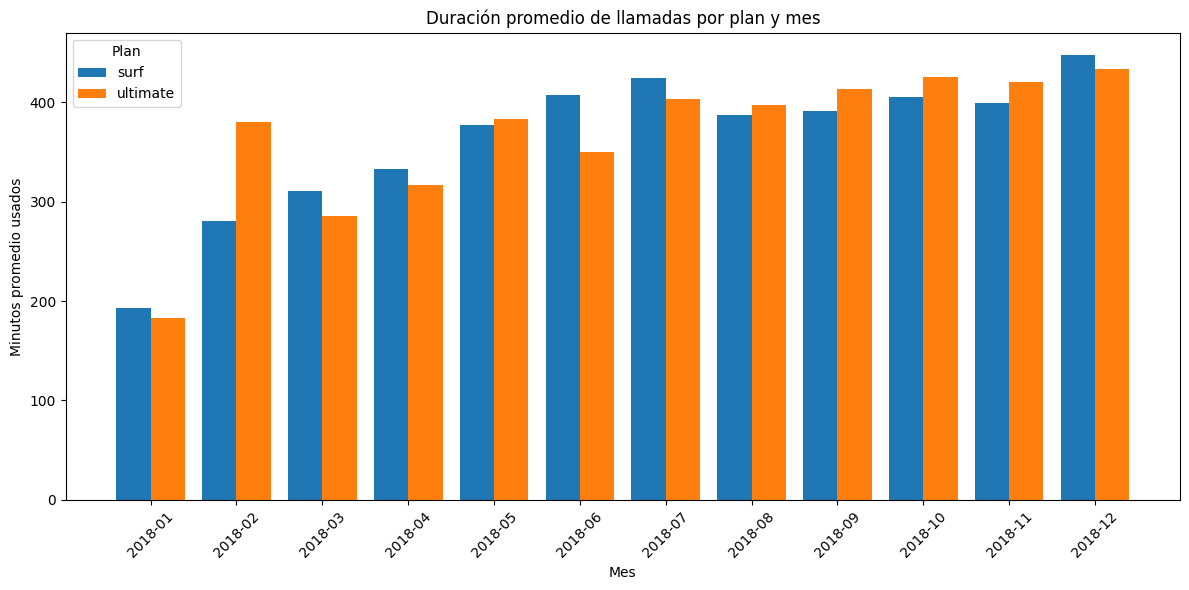

In [68]:
plan_order = ['surf', 'ultimate']


avg_minutes_per_plan = (
    usage
    .groupby(['plan', 'month'])['minutes_used']
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt
import numpy as np


surf_data = avg_minutes_per_plan[avg_minutes_per_plan['plan'] == 'surf']
ultimate_data = avg_minutes_per_plan[avg_minutes_per_plan['plan'] == 'ultimate']


months = surf_data['month'].astype(str)
x = np.arange(len(months))
width = 0.4

plt.figure(figsize=(12, 6))


plt.bar(x - width/2, surf_data['minutes_used'], width, label='surf')
plt.bar(x + width/2, ultimate_data['minutes_used'], width, label='ultimate')

plt.title('Duración promedio de llamadas por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Minutos promedio usados')
plt.xticks(x, months, rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()




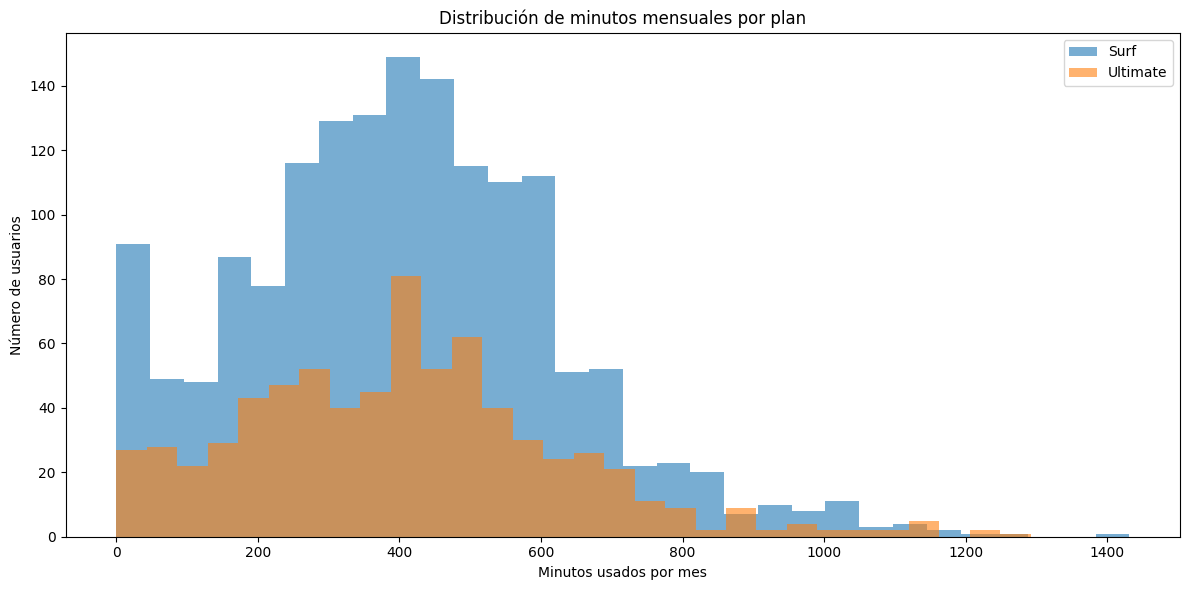

In [67]:
surf_minutes = usage[usage['plan'] == 'surf']['minutes_used']
ultimate_minutes = usage[usage['plan'] == 'ultimate']['minutes_used']

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(surf_minutes, bins=30, alpha=0.6, label='Surf')
plt.hist(ultimate_minutes, bins=30, alpha=0.6, label='Ultimate')

plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos usados por mes')
plt.ylabel('Número de usuarios')
plt.legend()
plt.tight_layout()
plt.show()

El histograma muestra la distribución del consumo mensual de minutos para ambos planes. Los usuarios del plan Surf presentan una mayor concentración de consumo entre valores medios, con una cola hacia la derecha que indica la presencia de usuarios que exceden los minutos incluidos en el plan.

Por otro lado, los usuarios del plan Ultimate muestran una distribución desplazada hacia valores más altos de consumo, aunque en la mayoría de los casos permanecen por debajo del límite incluido en la tarifa.

Estas diferencias sugieren que el plan Surf podría generar ingresos adicionales por cargos excedentes con mayor frecuencia, mientras que el plan Ultimate ofrece un consumo más holgado dentro de su cuota mensual.

In [40]:

call_stats = (
    usage
    .groupby('plan')['minutes_used']
    .agg(['mean', 'var'])
)

call_stats


,mean,var
plan,,
surf,404.762390,49135.104891
ultimate,406.193083,51640.971402


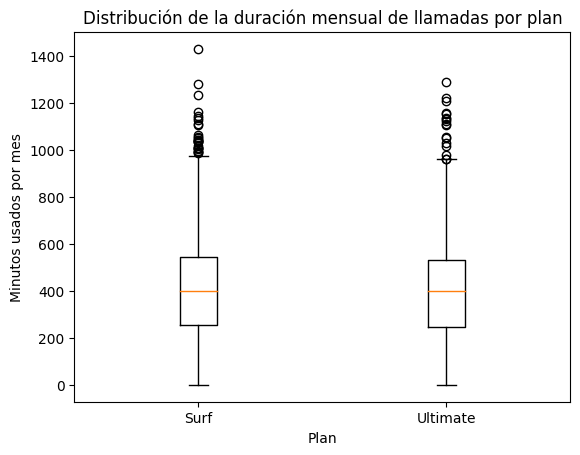

In [41]:

import matplotlib.pyplot as plt

# Filtrar los datos por plan
surf_minutes = usage[usage['plan'] == 'surf']['minutes_used']
ultimate_minutes = usage[usage['plan'] == 'ultimate']['minutes_used']

# Crear el boxplot
plt.figure()
plt.boxplot(
    [surf_minutes, ultimate_minutes],
    labels=['Surf', 'Ultimate']
)
plt.title('Distribución de la duración mensual de llamadas por plan')
plt.ylabel('Minutos usados por mes')
plt.xlabel('Plan')
plt.show()





El comportamiento de los usuarios respecto al uso de llamadas no presenta diferencias significativas entre los planes Surf y Ultimate. Ambos grupos muestran medianas y dispersiones similares, así como la presencia de valores atípicos elevados. Esto indica que el consumo de llamadas no depende fuertemente del plan contratado, y que otros factores del servicio pueden ser determinantes en la elección de la tarifa.

### Mensajes

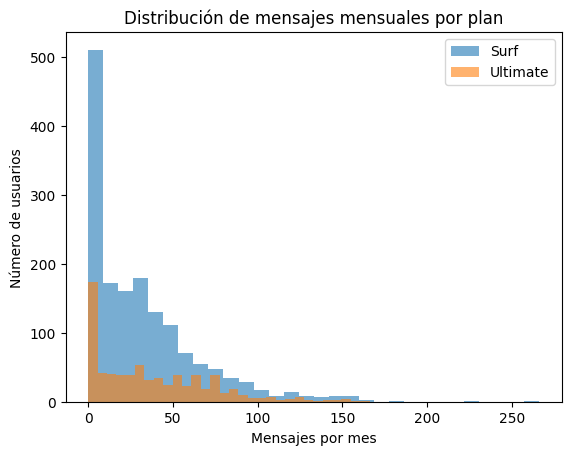

,mean,var
plan,,
surf,31.159568,1126.724522
ultimate,37.551389,1208.756744


In [44]:

import matplotlib.pyplot as plt


surf_messages = usage[usage['plan'] == 'surf']['messages_sent']
ultimate_messages = usage[usage['plan'] == 'ultimate']['messages_sent']


plt.hist(surf_messages, bins=30, alpha=0.6, label='Surf')
plt.hist(ultimate_messages, bins=30, alpha=0.6, label='Ultimate')
plt.xlabel('Mensajes por mes')
plt.ylabel('Número de usuarios')
plt.title('Distribución de mensajes mensuales por plan')
plt.legend()
plt.show()

usage.groupby('plan')['messages_sent'].agg(['mean', 'var'])

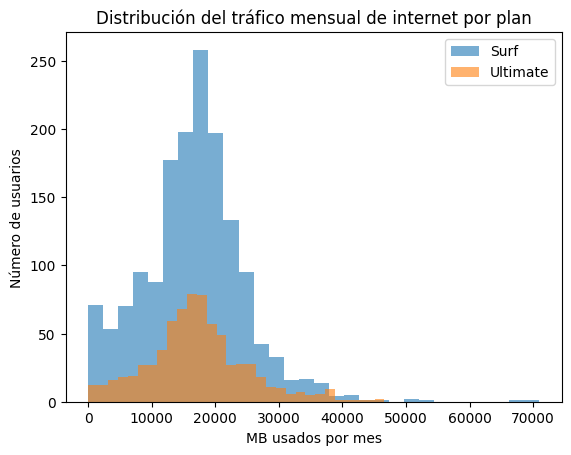

,mean,var
plan,,
surf,16558.283490,6.421640e+07
ultimate,17214.699694,6.165229e+07


In [45]:

surf_internet = usage[usage['plan'] == 'surf']['mb_used']
ultimate_internet = usage[usage['plan'] == 'ultimate']['mb_used']

plt.hist(surf_internet, bins=30, alpha=0.6, label='Surf')
plt.hist(ultimate_internet, bins=30, alpha=0.6, label='Ultimate')

plt.xlabel('MB usados por mes')
plt.ylabel('Número de usuarios')
plt.title('Distribución del tráfico mensual de internet por plan')
plt.legend()
plt.show()

usage.groupby('plan')['mb_used'].agg(['mean', 'var'])


Los usuarios del plan Ultimate tienden a enviar más mensajes y a consumir ligeramente más trafico de internet que los usuarios de los del plan Surf. Sin embargo, las diferencias en los promedios no son extremas, mientras que la variabilidad en ambos planes es alta. Esto indica que el comportamineto de los usuarios es heterogénei y que en una parte importante de los usuarios puede exceder los límites del plan, especialmente en el consumo de datos móviles.

### Internet

In [47]:
usage.groupby('plan')['mb_used'].agg(['mean', 'var'])

,mean,var
plan,,
surf,16558.283490,6.421640e+07
ultimate,17214.699694,6.165229e+07


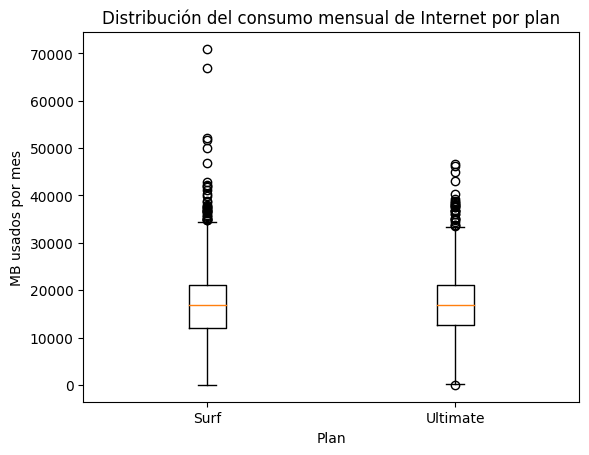

In [52]:
import matplotlib.pyplot as plt

surf_mb = usage[usage['plan'] == 'surf']['mb_used']
ultimate_mb = usage[usage['plan'] == 'ultimate']['mb_used']

plt.figure()
plt.boxplot([surf_mb, ultimate_mb], labels=['Surf', 'Ultimate'])
plt.title('Distribución del consumo mensual de Internet por plan')
plt.ylabel('MB usados por mes')
plt.xlabel('Plan')
plt.show()


El consumo mensual de tráfico de internet es elevado en ambos planes y presenta una alta variabilidad. Los usuarios del plan Ultimate consumen, en promedio, ligeramente más datos que los del plan Surf, aunque la diferencia no es considerable. La alta varianza indica que el comportamiento de los usuarios es heterogéneo, con algunos usuarios consumiendo grandes volúmenes de datos mensuales. En general, el patrón de consumo es similar entre planes, pero los límites del plan Surf pueden provocar cargos adicionales con mayor frecuencia.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [57]:
usage.groupby('plan')['monthly_revenue'].agg(['mean', 'var'])

,mean,var
plan,,
surf,60.327346,3053.955465
ultimate,72.313889,129.848486


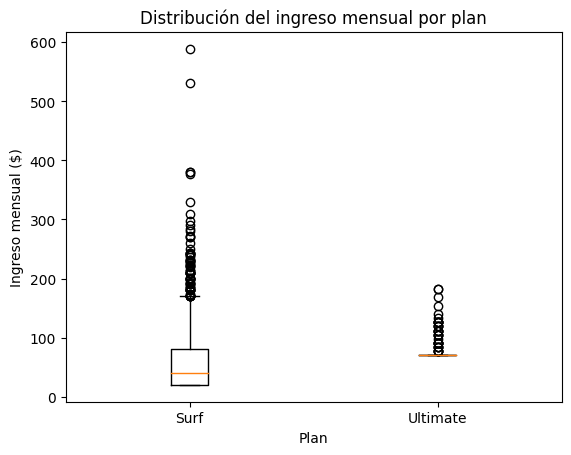

In [59]:
surf_rev = usage[usage['plan'] == 'surf']['monthly_revenue']
ultimate_rev = usage[usage['plan'] == 'ultimate']['monthly_revenue']

plt.figure()
plt.boxplot([surf_rev, ultimate_rev], labels=['Surf', 'Ultimate'])
plt.title('Distribución del ingreso mensual por plan')
plt.ylabel('Ingreso mensual ($)')
plt.xlabel('Plan')
plt.show()


El ingreso mensual promedio generado por los usuarios del plan Ultimate es mayor que el del plan Surf. Aunque el plan Surf tiene una tarifa base más baja, los usuarios con frecuencia exceden los límites incluidos, lo que genera cargos adicionales. Sin embargo, el plan Ultimate resulta más estable en términos de ingresos, con menor variabilidad relativa, lo que sugiere que es un plan más rentable y predecible para la empresa.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Excelente trabajo con las visualizaciones de datos. Además, calculaste correctamente la información estadística de cada distribución de datos, tanto para el consumo de minutos, mensajes e internet, como para los ingresos asociados a los cobros mensuales en cada plan. Esto permite identificar patrones de comportamiento en los usuarios y extraer información valiosa para la compañía.

</div>

## Prueba las hipótesis estadísticas

In [62]:
from scipy import stats

surf_revenue = usage[usage['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = usage[usage['plan'] == 'ultimate']['monthly_revenue']

alpha = 0.05

t_stat, p_value = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print('p-value:', p_value)

if p_value < alpha:
    print('Se rechaza la hipótesis nula')
else:
    print('No se rechaza la hipótesis nula')



p-value: 3.5320199509520717e-16
Se rechaza la hipótesis nula


Hipótesis nula (H₀): El ingreso promedio de los usuarios del plan Surf es igual al del plan Ultimate.
Hipótesis alternativa (H₁): El ingreso promedio de los usuarios del plan Surf es diferente al del plan Ultimate.

Para evaluar esta hipótesis se utilizó una prueba t de Student para muestras independientes, aplicando la corrección de Welch, debido a que no se puede asumir igualdad de varianzas entre los grupos. El nivel de significancia establecido fue α = 0.05.

El valor p obtenido fue significativamente menor que el nivel de significancia (p ≪ 0.05), por lo que se rechaza la hipótesis nula.

Esto indica que existe una diferencia estadísticamente significativa entre los ingresos promedio generados por los usuarios de los planes Surf y Ultimate, siendo el plan Ultimate el que genera mayores ingresos en promedio.

In [66]:
usage = usage.merge(
    users[['user_id', 'city']], 
    on='user_id', 
    how='left'
)


ny_nj_revenue = usage[usage['city'].str.contains('NY-NJ')]['monthly_revenue']
other_revenue = usage[~usage['city'].str.contains('NY-NJ')]['monthly_revenue']

t_stat, p_value = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)

print('p-value:', p_value)

if p_value < alpha:
    print('Se rechaza la hipótesis nula')
else:
    print('No se rechaza la hipótesis nula')




p-value: 0.031214139070912954
Se rechaza la hipótesis nula


Hipótesis nula (H₀): El ingreso promedio de los usuarios del área NY–NJ es igual al de los usuarios de otras regiones.
Hipótesis alternativa (H₁): El ingreso promedio de los usuarios del área NY–NJ es diferente al de los usuarios de otras regiones.

Se aplicó una prueba t de Student para muestras independientes con corrección de Welch y un nivel de significancia de α = 0.05.

El valor p obtenido fue menor que el nivel de significancia establecido (p < 0.05), por lo que se rechaza la hipótesis nula.

Este resultado sugiere que existe una diferencia estadísticamente significativa entre el ingreso promedio de los usuarios del área NY–NJ y el de los usuarios de otras regiones, lo cual podría estar relacionado con diferencias en patrones de consumo o características demográficas de dichas áreas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Marcos aplicaste correctamente las pruebas de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>


Te recomiendo realizar previamente una prueba de  [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la prueba t sea estadísticamente válida.
</div>
</div>

## Conclusión general

Preparación y limpieza de datos
Los conjuntos de datos fueron revisados individualmente para verificar tipos de datos, valores ausentes y coherencia con el diccionario de datos. Se confirmó que no existían errores críticos y se realizaron conversiones necesarias (fechas a datetime y creación del periodo mensual) para permitir agregaciones correctas.

Criterio de agregación mensual
Dado que las tarifas y los cobros se aplican de forma mensual, los datos de llamadas, mensajes y tráfico de internet se agregaron por usuario y por mes, lo que permitió representar correctamente el consumo real y evitar duplicidades en el análisis.

Cálculo del consumo bajo las reglas del operador
Se respetaron las condiciones establecidas por Megaline, incluyendo el redondeo de minutos por llamada y el redondeo del consumo de datos a gigabytes por mes, asegurando que el cálculo del ingreso reflejara fielmente la política de cobro.

Cálculo del ingreso mensual por usuario
El ingreso mensual se calculó considerando la tarifa base de cada plan y los cargos adicionales únicamente cuando el consumo excedía los límites incluidos, lo cual permitió obtener una estimación realista del ingreso generado por cada usuario.

Comportamiento de uso por plan
El análisis descriptivo mostró que los usuarios del plan Ultimate tienden a consumir más minutos, enviar más mensajes y utilizar más datos que los usuarios del plan Surf, aunque ambos planes presentan distribuciones con valores atípicos.

Elección de métodos estadísticos
Para comparar ingresos promedio se utilizó la prueba t de Student para muestras independientes con corrección de Welch, debido a que no se asumió igualdad de varianzas entre los grupos. Se estableció un nivel de significancia estándar de α = 0.05.

Diferencia de ingresos entre planes
La prueba de hipótesis mostró que existe una diferencia estadísticamente significativa entre los ingresos promedio de los planes Surf y Ultimate, concluyendo que el plan Ultimate genera mayores ingresos en promedio.

Diferencias regionales de ingreso
El análisis estadístico indicó que el ingreso promedio de los usuarios del área NY–NJ difiere significativamente del ingreso de los usuarios de otras regiones, lo que sugiere posibles diferencias en patrones de consumo regionales.

Limitaciones del análisis
El estudio se basó en una muestra relativamente pequeña de usuarios y en un periodo de tiempo limitado a un año, por lo que los resultados deben interpretarse como un análisis preliminar y no como una generalización absoluta.

Conclusión estratégica
Con base en los resultados obtenidos, el plan Ultimate es más rentable para la empresa Megaline, por lo que se recomienda priorizar este plan en estrategias de marketing y publicidad para maximizar los ingresos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Desde el inicio de tu conclusión se percibe un enfoque ordenado que articula la preparación de los datos con las decisiones analíticas posteriores, lo que aporta coherencia a todo el proceso. La forma en que alineas la agregación mensual con las reglas del operador demuestra una correcta comprensión del contexto del negocio y permite que los cálculos de ingreso sean consistentes con la realidad operativa.

</div>